# spaCy Example: Real-Time Bitcoin Sentiment Analysis

This notebook demonstrates the end-to-end functionality of the Bitcoin sentiment analysis pipeline, using the `BitcoinSentimentAnalyzer` class from `spacy_utils.py`. It scrapes Bitcoin-related tweets, preprocesses them, analyzes sentiment, correlates with Bitcoin prices, and visualizes the results.

## Step 1: Data Ingestion - Scrape Tweets

We use the `BitcoinSentimentAnalyzer` class to scrape tweets containing the keywords 'Bitcoin' and 'BTC'. The scraped tweets are stored in a DataFrame for further processing.

In [3]:
from spacy_utils import BitcoinSentimentAnalyzer
import pandas as pd

# Initialize the analyzer with the ChromeDriver path and X credentials
analyzer = BitcoinSentimentAnalyzer(
    chromedriver_path=r"C:\Users\siddh\src\tutorials1\DATA605\Spring2025\projects\TutorTask204_Spring2025_RealTime_Bitcoin_Sentiment_Analysis_spaCy_Selenium\chromedriver.exe",
    x_username="sidrohtest",
    x_password="siddhirohantesting#123"
)

# Scrape tweets
tweets = analyzer.scrape_tweets(keywords=["Bitcoin", "BTC"], max_tweets=100)

# Store tweets in a DataFrame
tweets_df = pd.DataFrame(tweets)
tweets_df.head()


,text,timestamp
0,This level is currently supporting #Bitcoin \n...,2025-05-16T20:14:05.289219
1,Bitcoin Ecology ＃src20#luffy\nJoin forces to ...,2025-05-16T20:14:05.305219
2,BREAKING PRESIDENT TRUMP'S EXECUTIVE DIRECTOR...,2025-05-16T20:14:07.337706
3,VanEck talking about sovereign demand for Bitc...,2025-05-16T20:14:07.346684
4,How can a debt based financial system survive ...,2025-05-16T20:14:07.354693


## Step 2: Data Preprocessing - Clean and Preprocess Tweets

We preprocess the tweets using the `preprocess_tweets` method from `BitcoinSentimentAnalyzer`, which cleans the text, tokenizes, lemmatizes, and extracts entities. Sentiment analysis is also performed to assign scores and categorize tweets.

In [4]:
# Preprocess tweets
processed_tweets = analyzer.preprocess_tweets(tweets)

# Analyze sentiment
tweets_with_sentiment = analyzer.analyze_sentiment(processed_tweets)

# Store processed tweets with sentiment in a DataFrame
processed_df = pd.DataFrame(tweets_with_sentiment)
processed_df[['text', 'sentiment', 'sentiment_category', 'coins']].head()


,text,sentiment,sentiment_category,coins
0,level currently support bitcoin end go want re...,0.2500,positive,[Bitcoin]
1,bitcoin ecology src20 join force create bitcoi...,0.5106,positive,[]
2,break president trump executive director digit...,0.5859,positive,[]
3,vaneck talk sovereign demand bitcoin huge,0.2023,positive,[Bitcoin]
4,debt base financial system survive exponential...,-0.3612,negative,[]


## Step 3: Correlation with Bitcoin Prices - Fetch Prices and Analyze Correlation

We fetch Bitcoin price data from CoinGecko using `fetch_bitcoin_price`, store it with sentiment scores, and compute multiple correlation measures using `correlate_sentiment_price`.

In [5]:
# Fetch Bitcoin price data
price_df = analyzer.fetch_bitcoin_price()

# Correlate sentiment with price
combined_df, correlations = analyzer.correlate_sentiment_price(tweets_with_sentiment, price_df)

# Display correlation coefficients
print("Correlation between sentiment and Bitcoin price:")
for method, value in correlations.items():
    print(f"{method.capitalize()}: {value:.4f}")

# Display the combined DataFrame
combined_df.head()


Correlation between sentiment and Bitcoin price:
Pearson: -0.0095
Spearman: -0.0818
Kendall: -0.0566
Lagged_pearson: -0.0108


,timestamp,sentiment,price_timestamp,price,price_change,cumulative_sentiment,sentiment_lagged,rolling_corr
0,2025-05-16 20:14:05.289219,0.2500,2025-05-16 00:15:45.218,103846.096421,NaN,0.2500,NaN,0.00000
1,2025-05-16 20:14:05.305219,0.5106,2025-05-16 00:20:22.865,103867.686245,0.000208,0.7606,0.2500,0.00000
2,2025-05-16 20:14:07.337706,0.5859,2025-05-16 00:25:26.717,103878.704289,0.000106,1.3465,0.5106,0.00000
3,2025-05-16 20:14:07.346684,0.2023,2025-05-16 00:30:55.060,103849.517850,-0.000281,1.5488,0.5859,0.00000
4,2025-05-16 20:14:07.354693,-0.3612,2025-05-16 00:36:05.896,103893.151921,0.000420,1.1876,0.2023,-0.37438


## Step 4: Visualizations - Plot Sentiment and Price Trends

We create visualizations to explore sentiment and price trends using methods from `BitcoinSentimentAnalyzer`. The plots are displayed directly in the notebook, including a line plot of sentiment vs. price, a box plot of sentiment distribution, an area plot of cumulative sentiment, a correlation heatmap, and a rolling correlation plot.

Sentiment vs Bitcoin Price Over Time:


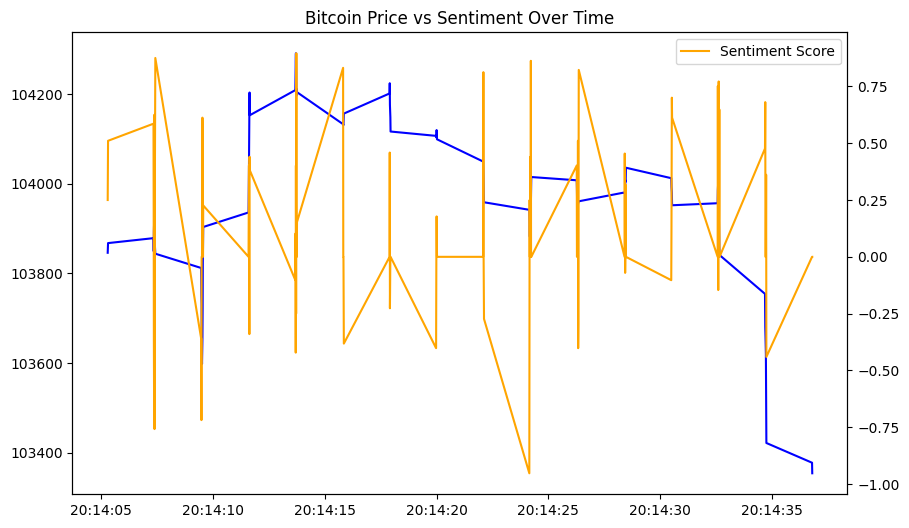

Sentiment Distribution (Box Plot):


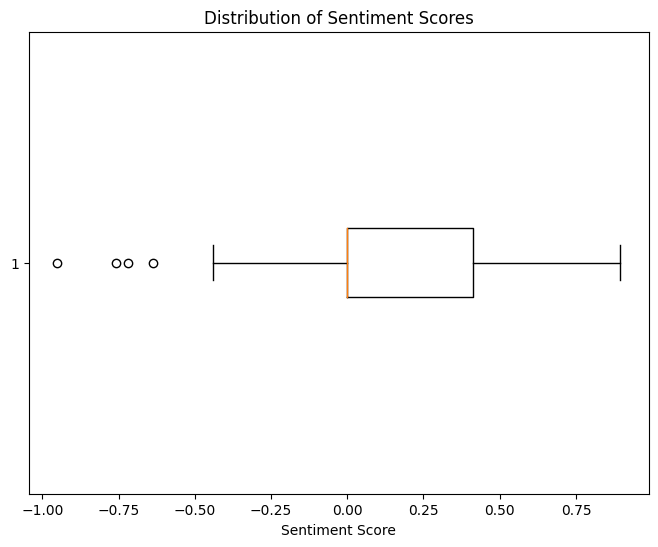

Cumulative Sentiment vs Bitcoin Price (Area Plot):


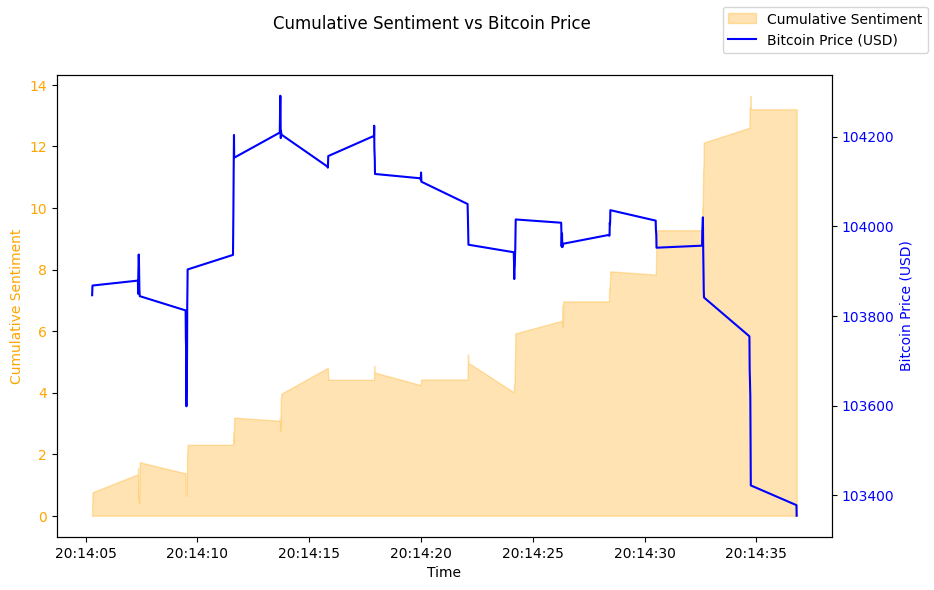

Correlation Heatmap (Sentiment, Price, Price Change, Rolling Correlation):


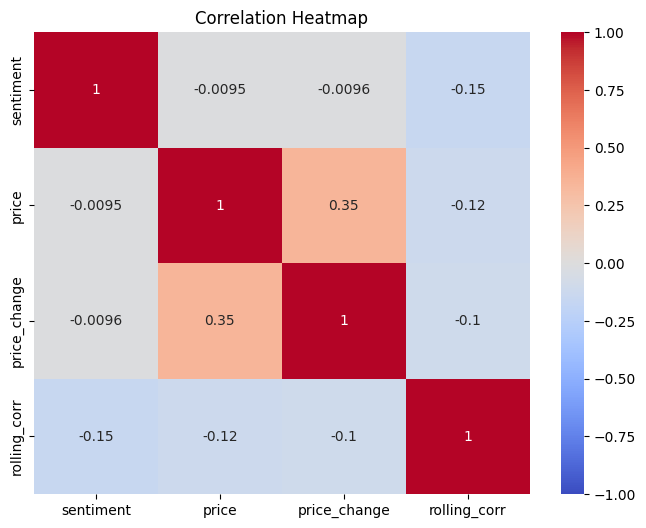

Rolling Correlation Between Sentiment and Price Over Time:


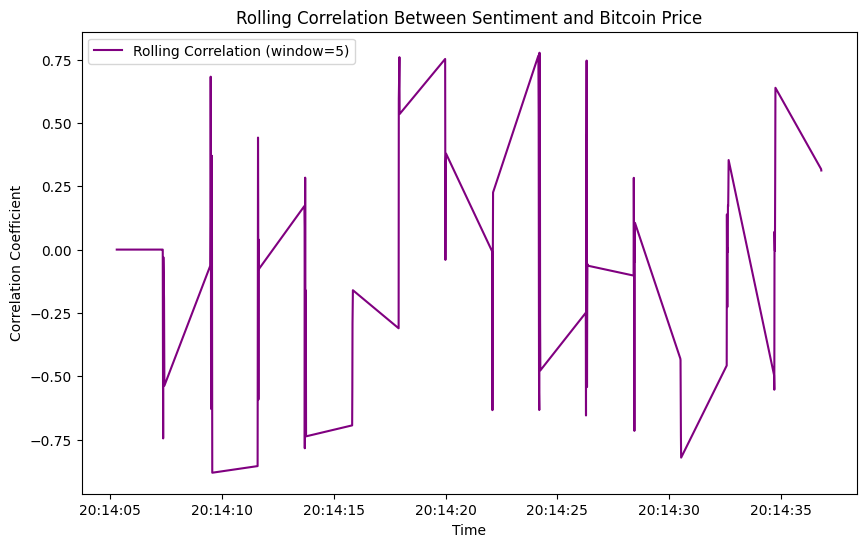

In [6]:
# Enable inline plotting
%matplotlib inline

# Visualize the data
print("Sentiment vs Bitcoin Price Over Time:")
analyzer.visualize_data(combined_df)

# Display Sentiment Distribution Box Plot
print("Sentiment Distribution (Box Plot):")
analyzer.visualize_sentiment_distribution_box(combined_df)

# Display Cumulative Sentiment Area Plot
print("Cumulative Sentiment vs Bitcoin Price (Area Plot):")
analyzer.visualize_cumulative_sentiment_area(combined_df)

# Display Correlation Heatmap
print("Correlation Heatmap (Sentiment, Price, Price Change, Rolling Correlation):")
analyzer.visualize_correlation_heatmap(combined_df)

# Display Rolling Correlation Plot
print("Rolling Correlation Between Sentiment and Price Over Time:")
analyzer.visualize_rolling_correlation(combined_df)


## Step 5: Cleanup

We clean up resources by deleting the analyzer instance, which closes the Selenium WebDriver.

In [7]:
# Clean up
del analyzer
